# 04 — Portfolio Optimization
Uses LSTM forecasts + LP model to find optimal capital allocation across EUR/USD, AUD/USD, NZD/USD.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from pathlib import Path

from ml.models.lstm_model import LSTMForecaster
from ml.models.model_utils import load_model
from ml.optimization import optimize_portfolio, equal_weight_portfolio, compare_strategies
from ml.optimization.risk_manager import compute_volatility

PAIRS         = ['EUR_USD', 'AUD_USD', 'NZD_USD']
PROCESSED_DIR = Path('../data/processed')
BUDGET        = 10_000.0   # USD
INVESTMENT_DAYS = 365
print('Setup complete.')

Setup complete.


## 1. Volatility Risk Profile

In [2]:
rows = []
for pair in PAIRS:
    stats = compute_volatility(pair)
    rows.append(stats)

risk_df = pd.DataFrame(rows).set_index('pair')
risk_df.style.format('{:.6f}')

,mean_vol,max_vol,latest_vol,annualised_vol
pair,,,,
EUR_USD,0.207013,0.491121,0.070500,3.286233
AUD_USD,0.188690,0.449732,0.183158,2.995367
NZD_USD,0.219276,0.444417,0.299421,3.480897


## 2. Get Forecast Returns from LSTM

In [3]:
forecast_returns = {}

for pair in PAIRS:
    X_test = torch.tensor(
        np.load(PROCESSED_DIR / pair / 'X_test.npy'), dtype=torch.float32
    )
    y_test = np.load(PROCESSED_DIR / pair / 'y_test.npy')

    # Load best saved model
    model = LSTMForecaster(input_size=X_test.shape[2])
    try:
        model = load_model(model, pair, tag='best')
        model.eval()
        with torch.no_grad():
            preds = model(X_test).numpy().squeeze()
        # Expected return = (last predicted price - first) / first
        forecast_return = float((preds[-1] - preds[0]) / (preds[0] + 1e-8))
    except FileNotFoundError:
        print(f'No model for {pair}, using 0.02 as placeholder.')
        forecast_return = 0.02

    forecast_returns[pair] = forecast_return
    print(f'{pair}: forecast_return = {forecast_return:.4f} ({forecast_return*100:.2f}%)')

EUR_USD: forecast_return = -0.0510 (-5.10%)
AUD_USD: forecast_return = 0.4426 (44.26%)
NZD_USD: forecast_return = 0.4212 (42.12%)


## 3. Run LP Optimizer

In [4]:
result = optimize_portfolio(
    forecast_returns=forecast_returns,
    budget=BUDGET,
    risk_tolerance='medium',
    min_weight=0.05,
    max_weight=0.60,
    investment_days=INVESTMENT_DAYS,
)

print(f"\nOptimal Allocation  (Budget: ${result['budget']:,.2f})")
print('-' * 45)
for pair in PAIRS:
    print(f"  {pair}: {result['allocations'][pair]*100:.1f}%  =  ${result['amounts'][pair]:,.2f}")
print(f"\nExpected Return : {result['expected_return_pct']*100:.2f}%")
print(f"Expected Amount : ${result['expected_amount']:,.2f}")


Optimal Allocation  (Budget: $10,000.00)
---------------------------------------------
  EUR_USD: 5.0%  =  $500.00
  AUD_USD: 60.0%  =  $6,000.00
  NZD_USD: 35.0%  =  $3,500.00

Expected Return : 44.82%
Expected Amount : $14,482.49


## 4. Compare LP vs Equal-Weight Strategy

In [5]:
strategies = compare_strategies(forecast_returns, budget=BUDGET, investment_days=INVESTMENT_DAYS)

rows = []
for s in strategies:
    row = {'Strategy': s['strategy'], 'Expected Return %': s['expected_return_pct'] * 100,
           'Expected Amount $': s['expected_amount']}
    for pair in PAIRS:
        row[f'{pair} %'] = s['allocations'][pair] * 100
    rows.append(row)

pd.DataFrame(rows).set_index('Strategy').style.format('{:.2f}')

,Expected Return %,Expected Amount $,EUR_USD %,AUD_USD %,NZD_USD %
Strategy,,,,,
lp_optimised,44.82,14482.49,5.00,60.00,35.00
equal_weight,30.39,13039.13,33.33,33.33,33.33


## 5. Allocation Visualisation

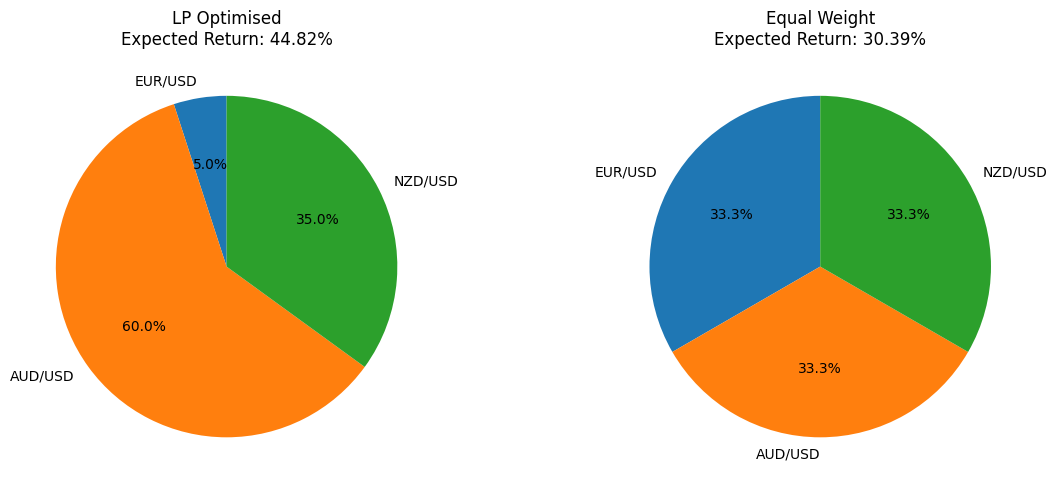

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
labels = [p.replace('_', '/') for p in PAIRS]

for ax, s in zip(axes, strategies):
    sizes = [s['allocations'][p] * 100 for p in PAIRS]
    ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
    title = 'LP Optimised' if s['strategy'] == 'lp_optimised' else 'Equal Weight'
    ax.set_title(f"{title}\nExpected Return: {s['expected_return_pct']*100:.2f}%")

plt.tight_layout()
plt.savefig('../data/processed/portfolio_comparison.png', dpi=150)
plt.show()

## 6. Sensitivity Analysis — Risk Tolerance

In [7]:
from ml.optimization.portfolio_optimizer import optimize_portfolio
import logging
logging.disable(logging.CRITICAL)   # suppress logs for clean output

rows = []
for tol in ['low', 'medium', 'high']:
    r = optimize_portfolio(forecast_returns, budget=BUDGET, risk_tolerance=tol)
    row = {'Risk Tolerance': tol, 'Expected Return %': r['expected_return_pct'] * 100,
           'Expected Amount $': r['expected_amount']}
    for pair in PAIRS:
        row[f'{pair} %'] = r['allocations'][pair] * 100
    rows.append(row)

logging.disable(logging.NOTSET)
pd.DataFrame(rows).set_index('Risk Tolerance').style.format('{:.2f}')

,Expected Return %,Expected Amount $,EUR_USD %,AUD_USD %,NZD_USD %
Risk Tolerance,,,,,
low,44.82,14482.49,5.00,60.00,35.00
medium,44.82,14482.49,5.00,60.00,35.00
high,44.82,14482.49,5.00,60.00,35.00
